In [1]:
#234567890#234567890#234567890#234567890#234567890#234567890#234567890#23456789
import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.optim import Adam, SGD
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets

In [2]:
IMG = '../../img'

In [3]:
#!mkdir ../../img/FMNIST

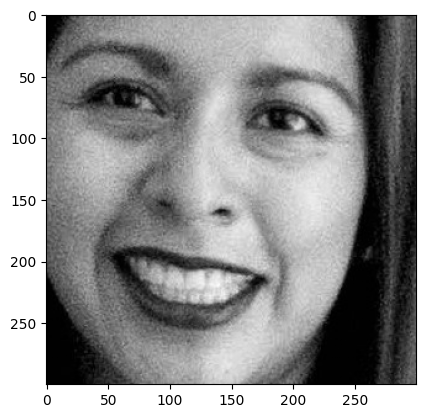

In [4]:
img = cv2.imread(f'{IMG}/face.jpeg')
img = img[200:500, 100:400]
img_grey = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(img_grey, cmap='gray');

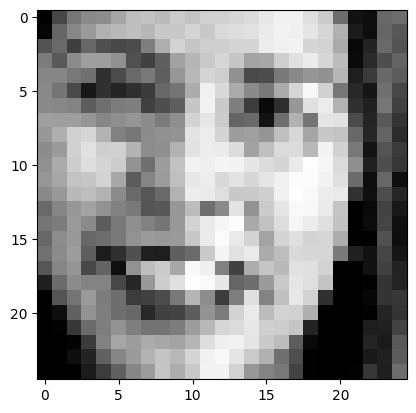

In [5]:
img_grey_small = cv2.resize(img_grey, (25, 25))
plt.imshow(img_grey_small, cmap='gray');

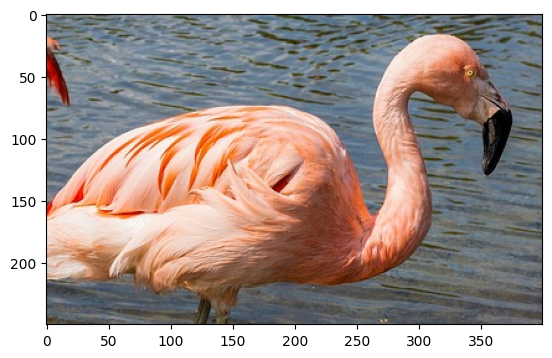

In [6]:
img = cv2.imread(f'{IMG}/flamingos.jpg')
img = img[150:400, 300:700]
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img);

In [7]:
data_folder = f'{IMG}/FMNIST'
fmnist = datasets.FashionMNIST(data_folder, download=True, train=True)

In [8]:
tr_imgs = fmnist.data
tr_targets = fmnist.targets

In [9]:
unique_vals = tr_targets.unique()
print(f'X: {tr_imgs.shape}\nY: {tr_targets.shape}\nY vals: {unique_vals}')
print(f'n classes: {len(unique_vals)}')
print(f'classes: {fmnist.classes}')

X: torch.Size([60000, 28, 28])
Y: torch.Size([60000])
Y vals: tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
n classes: 10
classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


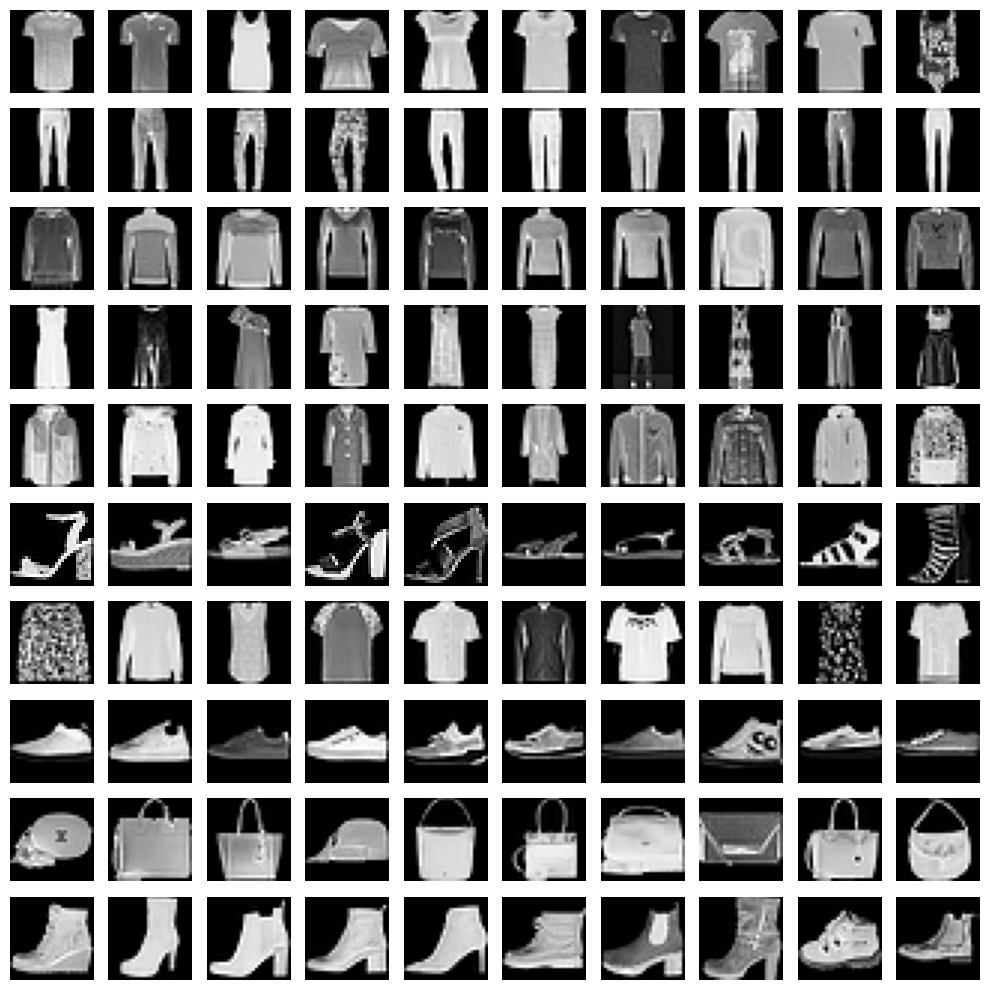

In [10]:
r, c = len(tr_targets.unique()), 10
fig, ax = plt.subplots(r, c, figsize=(10, 10))
for i, plot_row in enumerate(ax):
    label_x_rows = np.where(tr_targets == i)[0]
    for p in plot_row:
        p.grid(False)
        p.axis('off')
        idx = np.random.choice(label_x_rows)
        x, y = tr_imgs[idx], tr_targets[idx]
        p.imshow(x, cmap='gray')
plt.tight_layout();

In [11]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

In [12]:
class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float()
        x = x.view(-1, 28 * 28)
        self.x = x 
        self.y = y

    def __getitem__(self, i):
        x, y = self.x[i], self.y[i]
        return x.to(DEVICE), y.to(DEVICE)

    def __len__(self):
        return len(self.x)

In [13]:
def get_data(batch=32, shuffle=True):
    train = FMNISTDataset(tr_imgs, tr_targets)
    train_dl = DataLoader(train, batch_size=batch, shuffle=shuffle)
    return train_dl

In [14]:
def get_model(lr=1e-2):
    mod = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(DEVICE)
    loss_f = nn.CrossEntropyLoss()
    optim = SGD(mod.parameters(), lr=lr)
    return mod, loss_f, optim

In [15]:
def train_batch(x, y, mod, opt, loss_f):
    mod.train()
    preds = mod(x)
    batch_loss = loss_f(preds, y)
    batch_loss.backward()
    opt.step()
    opt.zero_grad()
    return batch_loss.item()

In [16]:
@torch.no_grad()
def accuracy(x, y, mod):
    mod.eval()
    preds = mod(x)
    max_vals, argmaxes = preds.max(-1)
    is_correct = argmaxes == y
    return is_correct.cpu().numpy().tolist()

In [17]:
trn_dl = get_data()
mod, loss_f, opt = get_model()

In [18]:
losses, accuracies = [], []

In [19]:
for epoch in range(5):
    print(epoch)
    epoch_losses, epoch_accs = [], []
    for i, batch in enumerate(iter(trn_dl)):
        x, y = batch
        batch_loss = train_batch(x, y, mod, opt, loss_f)
        epoch_losses.append(batch_loss)
    epoch_loss = np.array(epoch_losses).mean()
    for i, batch in enumerate(iter(trn_dl)):
        x, y = batch
        is_correct = accuracy(x, y, mod)
        epoch_accs.extend(is_correct)
    epoch_acc = np.mean(epoch_accs)
    losses.append(epoch_loss)
    accuracies.append(epoch_acc)

0
1
2
3
4


/var/folders/41/jhvt_zmd3nz3x5jsqblr221r0000gn/T/ipykernel_38043/1701507329.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels([f'{100 * x:.0f}%' for x in plt.gca().get_yticks()]);


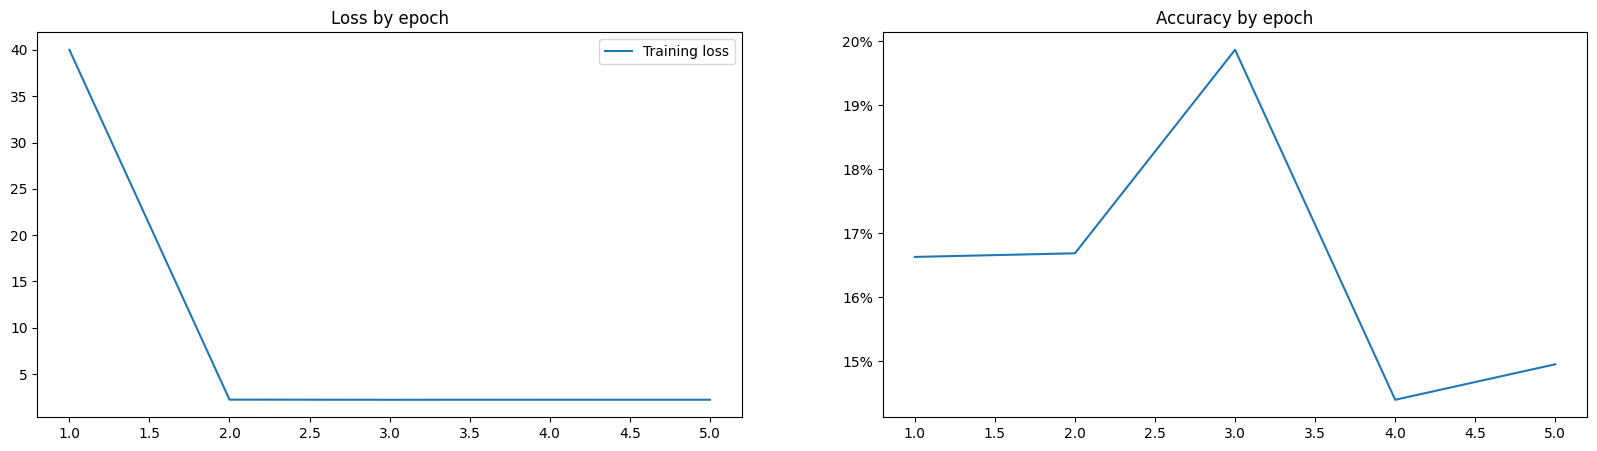

In [20]:
epochs = np.arange(5) + 1

plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plt.title('Loss by epoch')
plt.plot(epochs, losses, label='Training loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.title('Accuracy by epoch')
plt.plot(epochs, accuracies, label='Training accuracy')
plt.gca().set_yticklabels([f'{100 * x:.0f}%' for x in plt.gca().get_yticks()]);

In [21]:
class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float() / 255
        x = x.view(-1, 28 * 28)
        self.x, self.y = x, y

    def __getitem__(self, i):
        x, y = self.x[i], self.y[i]
        return x.to(DEVICE), y.to(DEVICE)

    def __len__(self):
        return len(self.x)

In [22]:
val_fmnist = datasets.FashionMNIST(data_folder, download=True, train=False)
val_imgs = val_fmnist.data
val_targets = val_fmnist.targets

In [23]:
def get_data(batch=32):
    train = FMNISTDataset(tr_imgs, tr_targets)
    trn_dl = DataLoader(train, batch_size=batch, shuffle=True)
    val = FMNISTDataset(val_imgs, val_targets)
    val_dl = DataLoader(val, batch_size=len(val_imgs), shuffle=False)
    return trn_dl, val_dl

In [24]:
@torch.no_grad()
def val_loss(x, y, mod):
    mod.eval()
    preds = mod(x)
    loss = loss_f(preds, y)
    return loss.item()

In [25]:
trn_dl, val_dl = get_data()
mod, loss_f, opt = get_model()

In [26]:
train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

In [27]:
for epoch in range(5):
    print(epoch)
    train_epoch_loss, train_epoch_acc = [], []
    for i, batch in enumerate(iter(trn_dl)):
        x, y = batch
        batch_loss = train_batch(x, y, mod, opt, loss_f)
        train_epoch_loss.append(batch_loss)
    train_epoch_loss = np.array(train_epoch_loss).mean()
    for i, batch in enumerate(iter(trn_dl)):
        x, y = batch
        is_correct = accuracy(x, y, mod)
        train_epoch_acc.extend(is_correct)
    train_epoch_acc = np.mean(train_epoch_acc)
    for i, batch in enumerate(iter(val_dl)):
        x, y = batch
        val_correct = accuracy(x, y, mod)
        valid_loss = val_loss(x, y, mod)
    val_epoch_acc = np.mean(val_correct)
    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_acc)
    val_losses.append(valid_loss)  ###
    val_accuracies.append(val_epoch_acc)

0
1
2
3
4


In [28]:
def get_model():
    mod = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(DEVICE)
    loss_f = nn.CrossEntropyLoss()
    opt = SGD(mod.parameters(), lr=1e-2)
    return mod, loss_f, opt

In [ ]:
class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float() / 255
        x = x.view(-1, 28 * 28)
        self.x, self.y = x, y

    def __getitem__(self, i):
        x, y = self.x[i], self.y[i]
        return x.to(DEVICE), y.to(DEVICE)

    def __len__(self):
        return len(self.x)